In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
x = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print('Shape: ', x.shape)
print('Distribusi Target: ')
print(pd.Series(y).value_counts(normalize=True).round(3))

Shape:  (569, 30)
Distribusi Target: 
1    0.627
0    0.373
Name: proportion, dtype: float64


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_tr, x_te, y_tr, y_te = train_test_split(x, y, random_state=42, stratify=y)

scaler = StandardScaler()
x_tr_s = scaler.fit_transform(x_tr)
x_te_s = scaler.transform(x_te)

In [3]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=6000)
log_model.fit(x_tr_s, y_tr)

y_pred_log = log_model.predict(x_te_s)

coef_df = pd.DataFrame({
    'Fitur': x.columns,
    'Koefisien': log_model.coef_[0]
}).sort_values('Koefisien', key=abs, ascending=False)

print(coef_df.head())

                   Fitur  Koefisien
21         worst texture  -1.250149
10          radius error  -1.070102
28        worst symmetry  -0.957045
27  worst concave points  -0.941888
13            area error  -0.941059


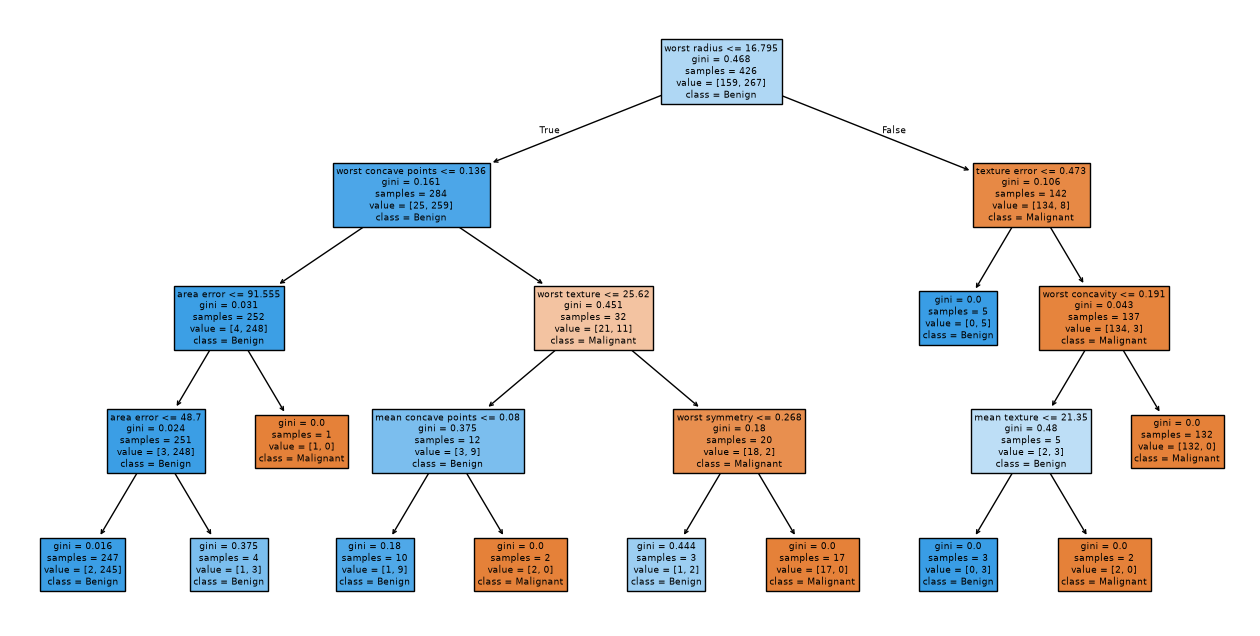

In [5]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

treeModel = DecisionTreeClassifier(max_depth=4, random_state=42)
treeModel.fit(x_tr, y_tr)
y_pred_tree = treeModel.predict(x_te)

plt.figure(figsize=(16,8))

plot_tree(treeModel, feature_names=x.columns, class_names=['Malignant', 'Benign'], filled=True)
plt.show()

In [11]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

for name, y_pred in [('Logistic Regression', y_pred_log),('Decision Tree', y_pred_tree)]:
    print(f'\n=== {name} ===')
    print(confusion_matrix(y_te, y_pred))
    print(f'Accuracy: {accuracy_score(y_te, y_pred):.3f}')
    print(f'Precision: {precision_score(y_te, y_pred):.3f}')
    print(f'Recall: {recall_score(y_te, y_pred):.3f}')
    print(f'F1-Score: {f1_score(y_te, y_pred):.3f}')
    


=== Logistic Regression ===
[[52  1]
 [ 1 89]]
Accuracy: 0.986
Precision: 0.989
Recall: 0.989
F1-Score: 0.989

=== Decision Tree ===
[[49  4]
 [ 4 86]]
Accuracy: 0.944
Precision: 0.956
Recall: 0.956
F1-Score: 0.956


### Analisis Performa Model: Fokus pada Metrik Evaluasi Kanker

Berdasarkan Hasil diatas, dapat disimpulkan bahwa logistic regression memiliki hasil diatas decision tree.

Hal ini disimpulkan dengan Hasil accuracy, precision, recall, f1-score

dari data, Logistic regression memiliki recall score 98.9%, dibanding decision tree dengan skor 95.6%

### Mengapa Recall Penting?
Dalam kasus medis, Recall adalah metriks yang penting untuk dijadikan perbandingan, karena beberapa alasan berikut:
* **Konsekuensi False Negative (FN):** *False Negative* berarti model mendiagnosis pasien sehat padahal sebenarnya mereka mengidap kanker. Jika ini terjadi, pasien tidak akan mendapatkan pengobatan yang mereka butuhkan tepat waktu, yang bisa berakibat fatal bagi keselamatan jiwa pasien.
* **Kelemahan Accuracy:** Nilai *Accuracy* yang tinggi bisa menipu jika dataset tidak seimbang (imbalanced data). Sebagai contoh, jika ada 95 orang sehat dan 5 orang sakit kanker, model yang menebak semua orang "sehat" akan tetap memiliki *Accuracy* 95%. Namun, model tersebut gagal total karena melewatkan semua pasien kanker (Recall = 0%).
* **Recall meminimalkan FN:** Semakin tinggi nilai Recall, semakin sedikit pasien kanker yang terlewat oleh sistem. Dalam dunia medis, mendeteksi positif palsu (pasien sehat dikira kanker) jauh lebih aman karena bisa dikoreksi lewat tes lanjutan, daripada mendeteksi negatif palsu (pasien kanker dikira sehat).